In [3]:
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('Indian_housing_Delhi_data.csv')
df['house_size'] = (
    df['house_size']
    .str.replace(',', '', regex=False)
    .str.replace(' sq ft', '', regex=False)
    .astype(int)
)
print(df['house_size'].dtype)

df.drop(['SecurityDeposit','numBalconies','isNegotiable','priceSqFt','verificationDate'],axis=1,inplace=True)
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_fence) &
              (df['price'] <= upper_fence)]
x=df_clean['house_size'].values
y=df_clean['price'].values
df_clean.head()
print(df_clean['house_size'].min(), df_clean['house_size'].max())
print(df_clean['price'].min(), df_clean['price'].max())

NameError: name 'pd' is not defined

150 14521
3000 3010101


Performance (R-squared): 0.5417756731951959
number of iterations=99999
final cost=17195414789.15914
predicted value for 29 is 5960905.682650389


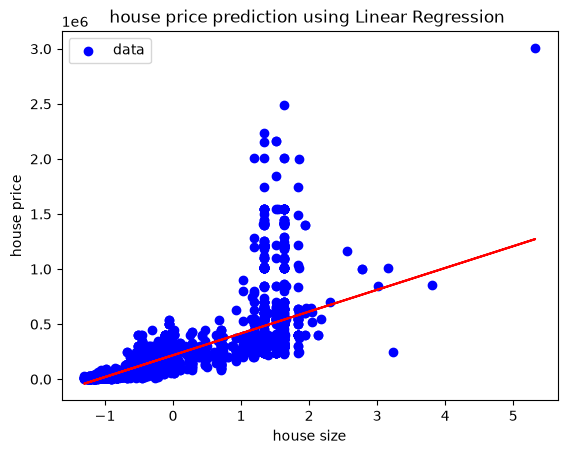

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def gradient_descent(x,y):
    learning_rate=0.00004
    m_curr=b_curr=0
    iterations=100000
    n=len(x)
    prev_cost = float('inf')
    for i in range(iterations):
        y_predicted=m_curr*x+b_curr     #y_predicted is an array of predicted y values based on current m array and b array
        cost=(1/(2*n))*sum([val**2 for val in (y-y_predicted)]) # cost is value 
        m_derivative=-(1/n)*sum(x*(y-y_predicted)) # slope of m
        b_derivative=-(1/n)*sum(y-y_predicted) # slope of b
        m_curr=m_curr-learning_rate*m_derivative # update m_curr by moving in the direction of the negative gradient using slope of m
        b_curr=b_curr-learning_rate*b_derivative # update b_curr by moving in the direction of the negative gradient using slope of b
        # if i % 100 == 0:
        #     print(f"{i} {m_curr} , {b_curr} , {cost}")
        if abs(prev_cost-cost) < 1e-9: # if the change in cost is very small, we can assume that we have reached a minimum
            break
        prev_cost = cost
    return m_curr,b_curr,cost,i
x= (x - x.mean()) / x.std()

gradient_descent(x,y)
value_of_m,value_of_b,cost,iteration=gradient_descent(x,y)

def performance(x,y,value_of_m,value_of_b):
    r_squared=1-(sum([val**2 for val in (y-(value_of_m*x+value_of_b))])/sum([val**2 for val in (y-(sum(y)/len(y)))]))
    print("Performance (R-squared):", r_squared)
performance(x,y,value_of_m,value_of_b)

print(f"number of iterations={iteration}")
print(f"final cost={cost}")
def predict(x_new,m,b):
    return m*x_new+b
x_new=29
print(f"predicted value for {x_new} is {predict(x_new,value_of_m,value_of_b)}")

plt.scatter(x, y, label="data", color='blue')
plt.plot(x, predict(x, value_of_m, value_of_b), color='red')
plt.xlabel("house size")
plt.ylabel("house price")
plt.legend()
plt.title("house price prediction using Linear Regression ")
plt.show()